# Job training: causal inference chapter 1-10

**Question:** How does enrolling in JTPA services affect subsequent earnings.

## 1. Research question and target population

The question we are seeking to answer is: "How does enrolling in JTPA services impact total earnings?"

- **Unit:** an adult in the JTPA research sample.
- **Outcome `Y`:** total earnings in the 30 months following random assignment.
- **Assignment" `Z`:** randomized offer of JTPA services.
- **Treatment `T`:** actual enrollment in JTPA services.

## 2. Data and preprocessing

Load the packages, verify the source data, and prepare baseline categories. These analyses are deterministic; no random seed is needed.

In [ ]:
from pathlib import Path
from hashlib import sha256
from importlib.metadata import version
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter
import statsmodels.formula.api as smf
from linearmodels.iv import IV2SLS
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 5), "figure.dpi": 110})
pd.set_option("display.max_columns", 25)

In [ ]:
# Locate the project from either its root or the notebooks directory.
PROJECT_ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "data/raw/jtpa.raw").is_file()
        and (path / "docs/data_dictionary.csv").is_file()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Start Jupyter inside job-training-causal-inference.")
RAW_DATA = PROJECT_ROOT / "data/raw/jtpa.raw"
Y, T, Z = "earnings_30mo", "enrolled", "offer"
print(f"Project: {PROJECT_ROOT}\nPython: {sys.version.split()[0]}")
print(
    " | ".join(
        f"{name} {version(name)}"
        for name in [
            "numpy",
            "pandas",
            "matplotlib",
            "seaborn",
            "statsmodels",
            "linearmodels",
        ]
    )
)

### Source and data checks

Source: [MIT's Angrist Data Archive](https://economics.mit.edu/people/faculty/josh-angrist/angrist-data-archive),
Abadie, Angrist, and Imbens (2002). The local source file has no header and uses
whitespace separators. Column positions follow the authors'
[replication code](https://economics.mit.edu/sites/default/files/inline-files/qeffectsfinal.m).

Read `data/README.md` for provenance. This is a prepared research extract:
fractional values in some covariates are preserved. Do not convert them to booleans
or assume an absence of nulls means the original measurements were complete.

In [ ]:
EXPECTED_SHA256 = "a662edacf90cc2d1298504c5e527c2289974be4eca01a6ea2075cca210dfdb4a"
if sha256(RAW_DATA.read_bytes()).hexdigest() != EXPECTED_SHA256:
    raise ValueError(
        "Source data differ from the verified MIT download; review provenance."
    )

dictionary = pd.read_csv(PROJECT_ROOT / "docs/data_dictionary.csv")
columns = dictionary.sort_values("source_column")["name"].tolist()
raw = pd.read_csv(RAW_DATA, sep=r"\s+", header=None, names=columns)
assert raw.shape == (11_204, len(columns)), "Unexpected source shape."
assert raw["person_id"].is_unique, "Expected one row per person."
assert raw[[Z, T, "male"]].isin([0, 1]).all().all()
assert raw[Y].ge(0).all()
df = raw.copy()
print(f"Loaded {len(raw):,} people and {raw.shape[1]} source columns.")
display(raw.head())

In [ ]:
display(dictionary)
display(
    pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "missing": df.isna().sum(),
            "unique_values": df.nunique(),
        }
    )
)

### Represent missing marital status and education explicitly

The data currently treats missing marital and education status by imputing a fractional value.  Marital status, for example, is using the proportion of people within that category that are married, split by men and women.  Since missing marital status may not be independant accross our sample, I will instead add an unknown category to marriage and education so we don't unintentionally bias our data.  Ultimately, either decision will not affect our model or standard errors much.  I do not recommend dropping the population with missing values as it will decrease our statistical strength and I do not know if missingness is independant of our outcome, which means dropping could lead to bias.

Note that treating missing as unknown is not without its own potential to increase bias: [Missing-indicator methods and their limitations](https://pmc.ncbi.nlm.nih.gov/articles/PMC3414599/)




The preprocessing below also applies the same Unknown-category rule to prior employment. Its observed source codes remain labelled 0 and 1 because their exact direction still needs verification. One helper prepares all three categorical controls before any plots or models; raw source values remain unchanged.

In [ ]:
def binary_with_unknown(series, labels):
    """Keep source 0/1; represent fractional or missing entries as Unknown."""
    unknown = series.isna() | (series.gt(0) & series.lt(1))
    if not (series.isin([0, 1]) | unknown).all():
        raise ValueError(f"Unexpected codes in {series.name}; inspect before recoding.")
    values = series.map({0: labels[0], 1: labels[1]}).fillna("Unknown")
    return pd.Categorical(values, categories=[*labels, "Unknown"])


# Start from raw so this cell is safe to rerun. No redundant unknown indicators.
df = raw.copy()
status_specs = {
    "married": ("married", ["Not married", "Married"]),
    "hsorged": ("hsorged", ["No diploma/GED", "Diploma/GED"]),
    "prior_employment_status": ("wkless13", ["Source 0", "Source 1"]),
}
for target, (source, labels) in status_specs.items():
    df[target] = binary_with_unknown(raw[source], labels)

unknown_status_summary = pd.DataFrame(
    [
        {
            "Variable": name,
            "Unknown": int(df[name].eq("Unknown").sum()),
            "Unknown share": df[name].eq("Unknown").mean(),
        }
        for name in status_specs
    ]
)
display(
    unknown_status_summary.style.hide(axis="index").format(
        {"Unknown": "{:,.0f}", "Unknown share": "{:.2%}"}
    )
)

# Use the same category coding in balance plots and in the regressions.
analysis_covariates = [
    "prior_employment_status" if name == "wkless13" else name
    for name in columns
    if name not in ["person_id", Y, T, Z]
]

## 3. Descriptive results and assignment balance

Inspect the earnings distribution, including zero earners. The log view is descriptive; the regression outcome remains total earnings in dollars.

In [ ]:
print(
    f"Zero earnings: {df[Y].eq(0).sum():,} of {len(df):,} people ({df[Y].eq(0).mean():.1%})"
)
display(df[Y].describe().to_frame("30-month earnings ($)").round(2))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df[Y], bins=50, color="#0072B2")
axes[0].set(
    title="Total earnings: original dollar scale",
    xlabel="30-month earnings ($)",
    ylabel="People",
)
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
axes[1].hist(np.log1p(df[Y]), bins=50, color="#0072B2")
axes[1].set(
    title="Log scale reveals the distribution",
    xlabel="ln(1 + 30-month earnings)",
    ylabel="People",
)
fig.tight_layout()
plt.show()
# Both plots include zero earners; all regression outcomes remain in dollars.

### Assignment balance

In [ ]:
def plot_assignment_balance(data, variables, title):
    """Compare distributions within assignment groups, not raw group sizes."""
    counts = data[Z].value_counts().reindex([0, 1], fill_value=0)
    labels = [
        f"{'Not offered' if z == 0 else 'Offered'} (n={counts[z]:,})" for z in [0, 1]
    ]
    nrows = (len(variables) + 2) // 3
    fig, axes = plt.subplots(nrows, 3, figsize=(15, 3.5 * nrows + 1), squeeze=False)
    for ax, name in zip(axes.flat, variables):
        shares = pd.crosstab(data[name], data[Z]).reindex(columns=[0, 1], fill_value=0)
        if data[name].isna().any():
            shares.loc["Missing"] = (
                data.loc[data[name].isna(), Z]
                .value_counts()
                .reindex([0, 1], fill_value=0)
            )
        shares = shares.div(counts, axis="columns") * 100
        positions = np.arange(len(shares))
        for z, offset, color in [(0, -0.19, "#0072B2"), (1, 0.19, "#D55E00")]:
            ax.bar(
                positions + offset, shares[z], width=0.38, color=color, label=labels[z]
            )
        ax.set(
            title=name,
            xlabel="Recorded covariate value",
            ylabel="Share within assignment group",
            ylim=(0, 100),
        )
        ax.set_xticks(
            positions, shares.index.astype(str), rotation=15 if len(shares) > 2 else 0
        )
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
        ax.grid(axis="x", visible=False)
    for ax in axes.flat[len(variables) :]:
        ax.set_visible(False)
    fig.legend(
        *axes.flat[0].get_legend_handles_labels(),
        loc="upper center",
        bbox_to_anchor=(0.5, 1 - 0.32 / fig.get_figheight()),
        ncol=2,
    )
    fig.suptitle(title, y=1 - 0.02 / fig.get_figheight(), fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 1 - 0.9 / fig.get_figheight()))
    plt.show()


review_timing = ["class_tr", "ojt_jsa", "f2sms"]
plot_assignment_balance(
    df,
    [x for x in analysis_covariates if x not in review_timing],
    "Baseline covariate distributions by assignment",
)
plot_assignment_balance(
    df, review_timing, "Additional variables: review causal role before adjustment"
)

### Results consistent with random assignment
These plots off a clear indication that the assignment is random accross our different covariates, as described by the study. 

## 4. DAG and proposed controls

I'll now draw a DAG which ill make it easier to determine potential confounders and which controls to use to imporve the regression.

- A **pretreatment common cause** of enrollment and earnings is a candidate confounder.
- A baseline **outcome predictor** can improve precision even without predicting enrollment.
- A variable that predicts **enrollment alone** is not automatically a useful control


This DAG records the causal assumptions guiding the analysis of **enrollment's total effect on 30-month earnings**. The arrows are proposed mechanisms, not conclusions established with any analytical or statistical significance.

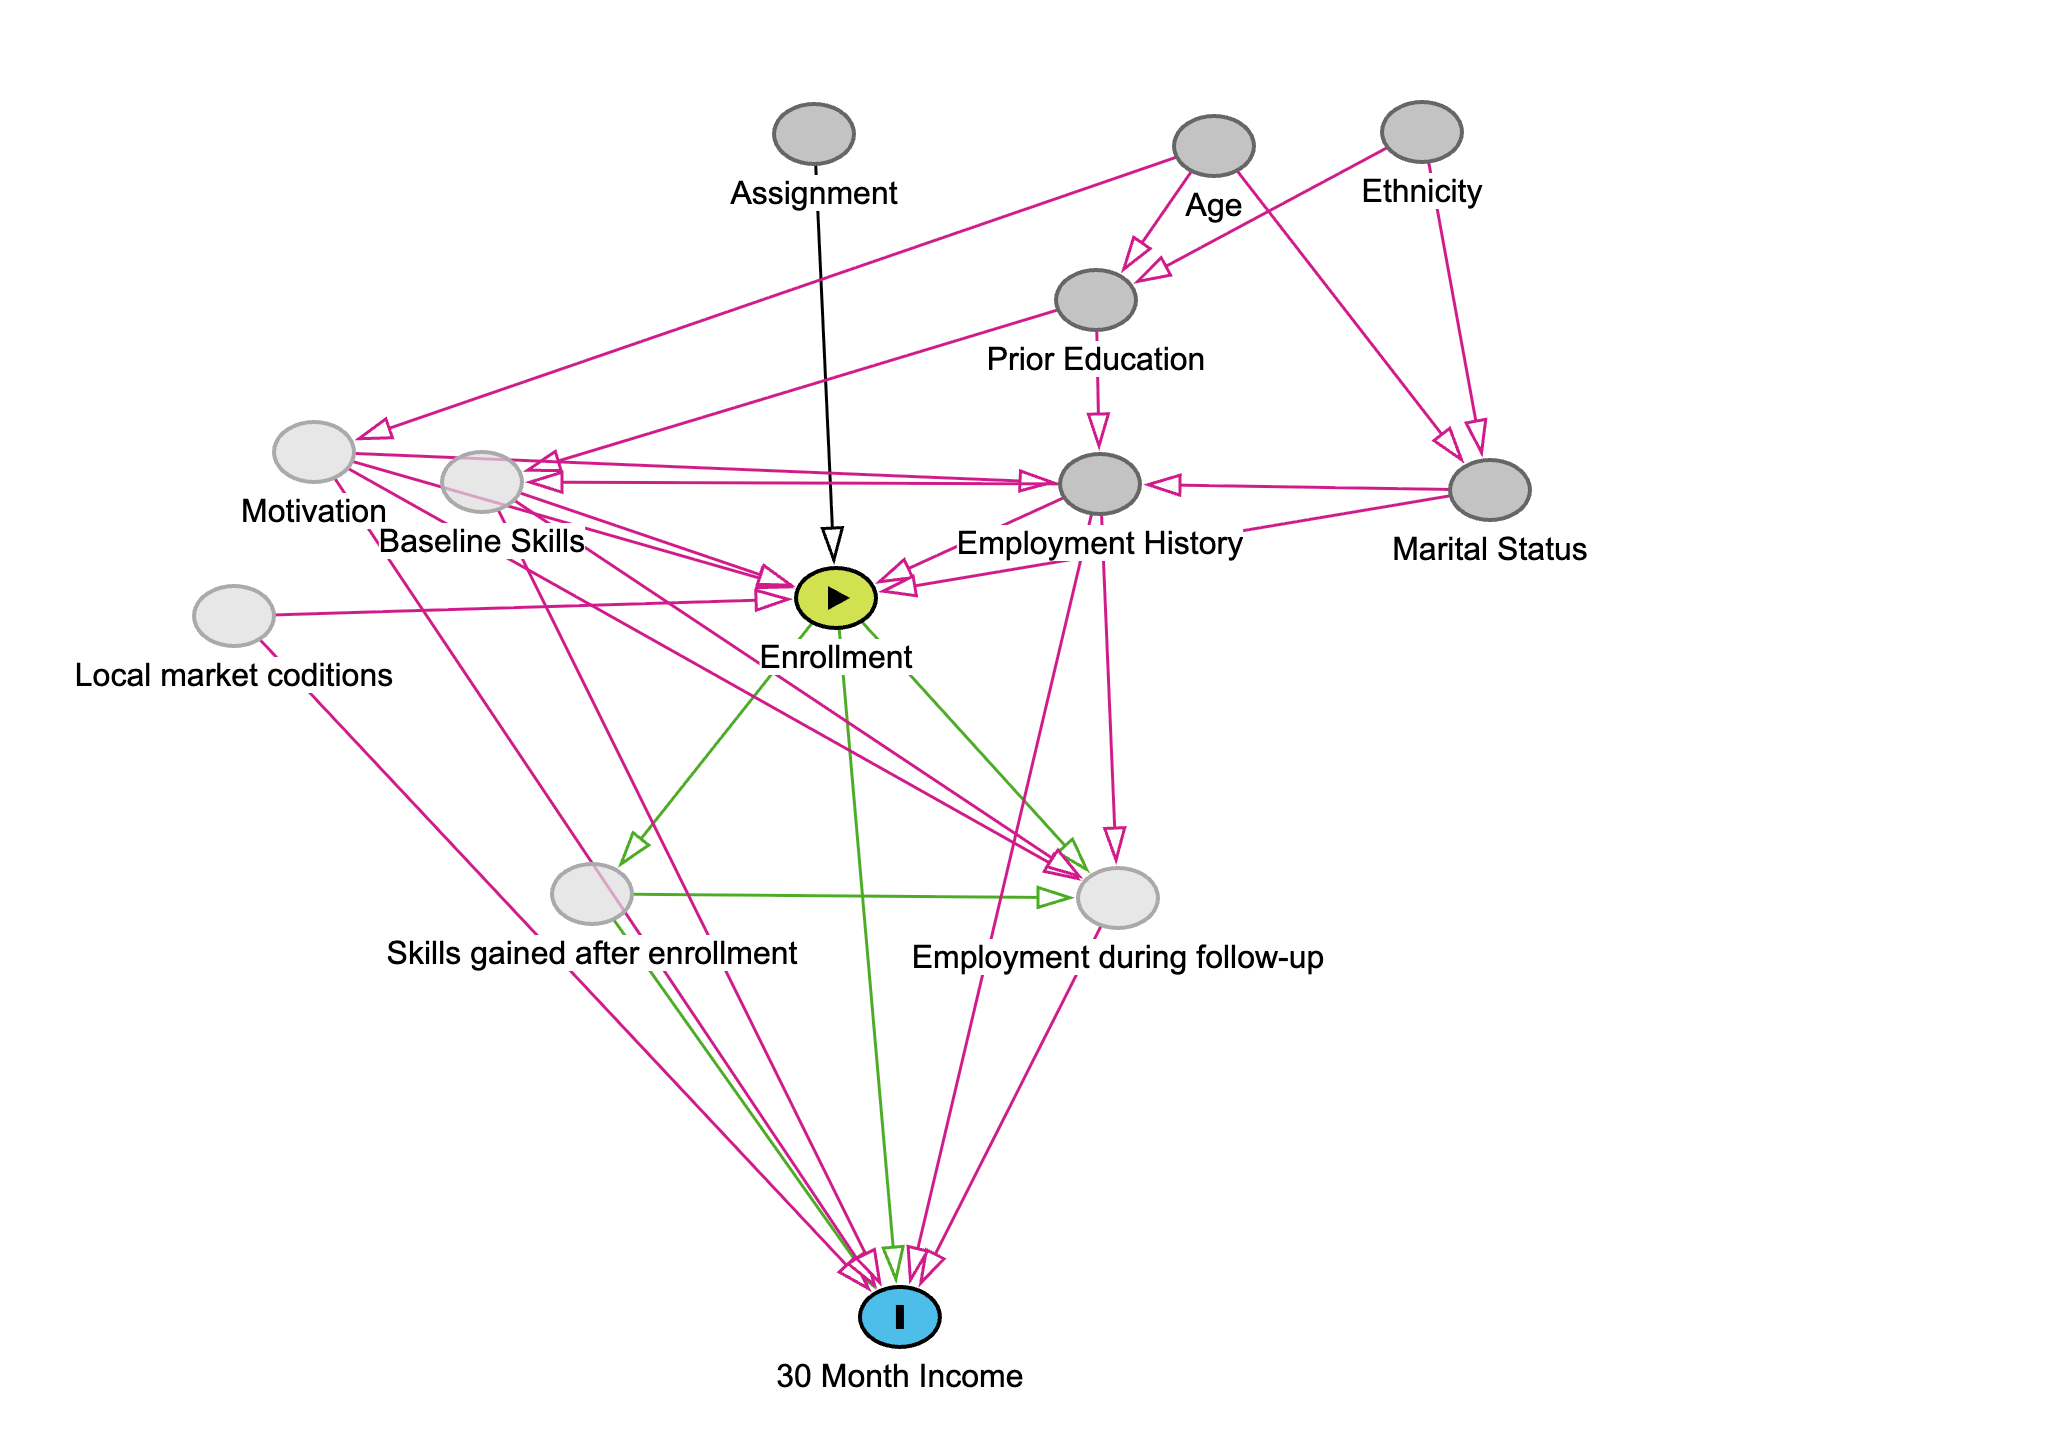

### One-line justification for each arrow

Baseline factors refer to circumstances before random assignment. Motivation is interpreted as longstanding; the marital-status-to-employment-history arrow assumes marital circumstances preceded the relevant work history. These timing assumptions are stronger than simply observing a variable at baseline. “Employment during follow-up” refers to obtaining and keeping a job, leaving room for other factors to affect wages and hours.

| Arrow | Proposed causal mechanism |
| --- | --- |
| Assignment → Enrollment | Being offered access to JTPA services makes enrollment more likely. |
| Age → Motivation | Life stage can change career priorities and willingness to invest in training. |
| Age → Prior Education | Older cohorts may have had more access to education |
| Age → Marital Status | Older cohorts are more likely to marry |
| Ethnicity → Prior Education | Educational sentiment may differ accross ethnicity |
| Ethnicity → Marital Status | Marriage patterns differe accross ethnicities |
| Prior Education → Baseline Skills | Schooling can develop skills already present before assignment. |
| Prior Education → Employment History | Educational credentials affect job access |
| Marital Status → Employment History | Married individuals may be less likely to need to work |
| Marital Status → Enrollment | Marrital status may affect ability to enroll, possibly through avenues like family status. |
| Motivation → Employment History | Motivated individuals are more likley to have found and retained employment |
| Motivation → Enrollment | Willingness to invest effort in career development can influence desire to participate in training. |
| Motivation → Employment during follow-up | Motivation can influence job search regardless of enrollment|
| Motivation → 30 Month Income | Effort and ambition can affect raises/pay |
| Employment History → Baseline Skills | Prior work experience develops skills |
| Employment History → Enrollment | Previous work experience can influence one's percieved need for aditional training|
| Employment History → Employment during follow-up | Prior experience and an existing network may influence future employment.
| Employment History → 30 Month Income | Experience can affect salary directly when being hired. |
| Baseline Skills → Enrollment | Existing skills can affect readiness for training and its perceived benefits. |
| Baseline Skills → Employment during follow-up | Existing abilities can affect hiring and job retention independently of training. |
| Baseline Skills → 30 Month Income | Existing skills can raise productivity and pay among people who obtain jobs. |
| Local market conditions → Enrollment | Available job opportunities can change the attractiveness of working immediately versus entering training. |
| Local market conditions → 30 Month Income | Labor demand and prevailing wages can affect subsequent earnings independently of enrollment. |
| Enrollment → Skills gained after enrollment | Participation in classes can build new skills|
| Enrollment → Employment during follow-up | Program referrals and job-search assistance can help participants find work. |
| Enrollment → 30 Month Income | Program support such as wage-negotiation guidance could affect pay through routes not captured by new skills or employment status. |
| Skills gained after enrollment → Employment during follow-up | New skills can improve eligibility for jobs and the ability to keep them. |
| Skills gained after enrollment → 30 Month Income | New skills can improve productivity and wages beyond their effect on obtaining a job. |
| Employment during follow-up → 30 Month Income | Obtaining and maintaining paid employment contributes to cumulative earnings during follow-up. |

**Implication for the analysis:** Notice how unobserved motivation, baseline skills, and local market conditions (among other unboserved covariates) leave enrollment confounded even after adjusting for measured baseline factors. Skills gained and employment during follow-up are mediators, so we will not adjust for them when estimating the total enrollment effect.

The fact that we cannot remove confounding from enrollment points strongly to using assignment as an instrument to determine a causal effect.  In order to 


### Main control set

Use age bands, prior education, marital status, prior employment, race/ethnicity indicators, and sex. Sex adds a baseline predictor beyond the current DAG. Education, marriage, and prior employment include Unknown categories. We omit post-enrollment mediators and measurement-source flags; recommended-service variables and AFDC are candidates for a separately justified sensitivity analysis. Define the control set here, before examining adjusted estimates.

In [ ]:
# Define each control once; use its categorical coding in the formula if needed.
age_columns = ["age2225", "age2629", "age3035", "age3644", "age4554"]
categorical_controls = list(status_specs)
control_columns = age_columns + categorical_controls + ["black", "hispanic", "male"]
baseline_controls = [
    f"C({name})" if name in categorical_controls else name for name in control_columns
]
control_terms = " + ".join(baseline_controls)
print("Baseline controls:", ", ".join(control_columns))

## 5. Enrollment, compliance, and IV assumptions

### Enrollment vs assignment

We can divide our population into four categories...

1. Assigned and enrolled
2. Assigned and unenrolled
3. Unassigned and enrolled
4. Unassigned and unenrolled

In [ ]:
# Z is assignment to an offer; T is actual enrollment.
# Keep all four combinations, even if a group has zero observations.
population_order = pd.MultiIndex.from_tuples(
    [(1, 1), (1, 0), (0, 1), (0, 0)], names=[Z, T]
)
population_counts = df.groupby([Z, T]).size().reindex(population_order, fill_value=0)

four_populations = pd.DataFrame(
    {
        "Population": [
            "Assigned and enrolled",
            "Assigned and unenrolled",
            "Unassigned and enrolled",
            "Unassigned and unenrolled",
        ],
        "Assigned (Z)": population_order.get_level_values(Z),
        "Enrolled (T)": population_order.get_level_values(T),
        "Count": population_counts.to_numpy(),
    }
)
four_populations["Share of sample"] = four_populations["Count"] / len(df)

# Divide each row by the total with the same assignment status.
# For enrolled rows, this is the enrollment rate within that assignment group.
assignment_totals = four_populations.groupby("Assigned (Z)")["Count"].transform("sum")
four_populations["Share within assignment group"] = (
    four_populations["Count"] / assignment_totals
)

print(f"Total sample: {len(df):,} people")
display(
    four_populations.style.hide(axis="index").format(
        {
            "Count": "{:,.0f}",
            "Share of sample": "{:.2%}",
            "Share within assignment group": "{:.2%}",
        }
    )
)

We can see that we have fairly strong compliance within the assigned population -- around 64%.  Additionally, we have extremely strong compliance within the unassigned population -- 98.55%.  

Now, we can indroduce some population classifiers as follows:

1. Compliers -- these people will do as they are assigned
2. Never Takers -- these people will never take the course, regardless of assignment
3. Always takers -- these people will always take the course, regardless of assignment
4. Defiers -- these people will do the opposite of what they are assigned

In practice, defiers are rare and often ignored in studies like these. By ignoring defiers, our assigned and unenrolled and unassigned and enrolled become pure proxies for never takers and always takers, allowing us to compute compliers cleanly.

1. Compliers: 62.71%
2. Never Takers: 35.84%
3. Always takers: 1.45%
4. Defiers: 0%

Notice too that this assumption of defiers as 0% isn't too harmful even if wrong -- because of the 1.45% cap on unassigned and enrolled, that is the absolute cap on the proportion of defiers in the popution.  This means that if we're wrong, we aren't wrong by much.  If we think that there is a small population of defiers, then we would have to adjust our estimates.

### Validate Instrument assumptions

We now propose using assignment as an instrument to estimate the causal effect of enrolling.  We need to establish 3 core IV conditions, plus monotonicity for the actual interpretation of our effect.

1. Relevance: Assignment must change the probability of enrollment -- confirmed via the data above
2. Independence: Assignment is independant of preexisiting covariates that may affect income or enrollment -- supported by balanced covariate groups above and via experimental design description
3. Exclusion: Assignment only affects earning through enrollment -- Receiving an offer to take a course would not intrinsically change job search, skills, etc...  We can argue for this by noting the recommendations preceeded assignment, so assignment really only affected access to services, not knowledge of services (for example, being assigned could lead someone to explore a different service type tehy wouldn't have thought of otherwise).  


Interpretation: Monotonicity -- i.e. we don't have defiers.  It's hard to make an argument that receiving an offer would make someone NOT want to take the class, while not receiving an offer would.



### Exclusion: the argument about program operations

Exclusion means that changing assignment while holding JTPA participation fixed would not change earnings. Randomization supports independence, but does not establish this restriction.

The study describes service recommendations as occurring **before random assignment**. Assignment then changed access to JTPA services; controls were generally barred for 18 months but could use other programs. These facts support an access-based interpretation, but do not rule out every alternative pathway. [Abadie, Angrist, and Imbens (2002), p. 100](https://economics.mit.edu/sites/default/files/publications/Instrumental%20Variables%20Estimates.pdf).

A defensible argument needs to consider whether assignment provided earnings-relevant information, referrals, or support outside recorded participation, or changed job search and alternative-program use even for people whose JTPA participation would stay the same. Alternative training is not automatically a violation: the concern is an assignment effect that bypasses the treatment as we have defined it. The treatment indicator must also capture the relevant service package and timing.

Our IV interpretation therefore assumes that assignment affects earnings only through JTPA participation and its consequences. This is a substantive assumption, not a result proven by balance plots or regression significance. The randomized offer effect remains informative if this exclusion assumption fails.


## 6. Assignment effect and enrollment association

Its useful to have a baseline for our estimated treament effect by using a couple of naive regressions.  We will use HC1 standard errors, allowing for unequal variance in the outcome accross groups.

In [ ]:
# Fix one common sample before fitting any model; keep the same people throughout.
model_sample = df[[Y, T, Z, *control_columns]].dropna().copy()
print(f"Common model sample: {len(model_sample):,} of {len(df):,} people")


def model_result(model, parameter, estimand):
    """Extract the same reporting fields from statsmodels OLS or linearmodels IV."""
    ci = model.conf_int().loc[parameter]
    se = model.std_errors if hasattr(model, "std_errors") else model.bse
    return {
        "Estimand": estimand,
        "Estimate ($)": model.params[parameter],
        "Robust SE ($)": se[parameter],
        "95% CI lower ($)": ci.iloc[0],
        "95% CI upper ($)": ci.iloc[1],
        "p-value": model.pvalues[parameter],
        "N": int(model.nobs),
    }

### Assignment effect (ITT)

In [ ]:
# The randomized-offer coefficient is the intention-to-treat effect.
naive_assignment_model = smf.ols(f"{Y} ~ {Z}", data=model_sample).fit(
    cov_type="HC1", use_t=True
)
display(naive_assignment_model.summary())

We see that if we regress assignment against earnings, those assigned to the course earn on average $1,159.43 more than those who are unassigned, with a statistically significant result.  This is a causal relationship due to randomization, and this estimate likely understates the impact of the course however, as only a 64% of those assigned to the course actually end up taking it.  

### Unadjusted enrollment association

In [ ]:
# This enrollment association can reflect selection as well as a treatment effect.
naive_enrollment_model = smf.ols(f"{Y} ~ {T}", data=model_sample).fit(
    cov_type="HC1", use_t=True
)
display(naive_enrollment_model.summary())

By regressing the enrolled population vs the outcome, we get a much larger effect size of 2,791.09.  This, however, likely overstates the causal effect, we we now have introduced the possibility of a confounder in our model by removing our random assignment assumption.  One potential confounder would be motivation to succeed -- those who are already motivated may be more likely to enroll AND more likely to earn more.  Therefore, motivation may affect both the treatment and the outcome, a classic confounder.  This is just a hypothesized confounder -- the key idea is that we now have bias in our estimated becasue of the existance of unmeasured or unknown factors that both influence enrollment and income.

## 7. Instrumental-variable estimates

### Uncontrolled IV

We instrument actual enrollment (`enrolled`) with randomized assignment (`offer`), including an intercept and no covariate controls. With a binary instrument, this 2SLS coefficient equals the Wald estimate:

$$
\widehat{\tau}_{IV}
= \frac{E_n[Y\mid Z=1]-E_n[Y\mid Z=0]}
       {E_n[T\mid Z=1]-E_n[T\mid Z=0]}.
$$

The denominator is the **difference** in enrollment rates: approximately 64.16% − 1.45% = **62.71 percentage points**, rather than just the assigned group's enrollment rate. Under relevance, independence, exclusion, and monotonicity (with a well-defined treatment and no interference), this estimates the average enrollment effect for **compliers**, not necessarily the effect for every participant.

Conceptually, 2SLS first predicts enrollment from assignment, then uses that predicted enrollment to explain earnings. The second stage uses fitted enrollment, not first-stage residuals. We use `IV2SLS` to compute the estimate and its covariance together: ordinary OLS standard errors from a manually fitted second stage are inappropriate.

We request `cov_type="robust", debiased=True`: heteroskedasticity-robust IV standard errors with an HC1-style $n/(n-k)$ correction and t-based confidence intervals. These account for estimation through the instrument and allow unequal error variances, assuming independent observations. “Debiased” refers to the covariance adjustment; it does not guarantee an unbiased causal estimate or validate the instrument. See the [IV2SLS fitting documentation](https://bashtage.github.io/linearmodels/iv/iv/linearmodels.iv.model.IV2SLS.fit.html).


In [ ]:
# No covariate controls; robust IV covariance with an HC1-style correction.
uncontrolled_iv_model = IV2SLS.from_formula(
    f"{Y} ~ 1 + [{T} ~ {Z}]", data=model_sample
).fit(cov_type="robust", debiased=True)
display(uncontrolled_iv_model.summary)

# With one binary instrument, 2SLS must equal the Wald ratio on the same sample.
group_means = model_sample.groupby(Z)[[Y, T]].mean()
itt = group_means.loc[1, Y] - group_means.loc[0, Y]
first_stage = group_means.loc[1, T] - group_means.loc[0, T]
wald = itt / first_stage
np.testing.assert_allclose(uncontrolled_iv_model.params[T], wald)
print(f"Wald check: ${itt:,.2f} / {first_stage:.5f} = ${wald:,.2f}")
print(
    f"Assignment changes enrollment by {first_stage:.2%} ({100 * first_stage:.2f} percentage points)."
)

#### Interpreting the IV estimate

It's important to explicitly name the effect we are measuring.  This is the average treatment effect of enrolling in the course for compliers -- people who will enroll if offered, and won't enroll if not. We can't individually identify these compliers, but we recover their effect by dividing the assignment earning difference by the differnce in proportion of people who enrolled after being offered vs those who enrolled after not being offered.

We get an estimate of $1848, with a standard error of 526.344.

### Controlled IV

We can safely control for age, education, marital status, prior employment, ethnicity, and sex, as they are measured before assignment and plausably relate to both enrollment and income.  The purpose of controlling for these covariates is not to change our estimate of the effect, which was already unbiased, but rather to reduce the standard error of that estimate!

In [ ]:
# Exogenous controls enter both stages automatically; assignment instruments enrollment.
controlled_iv_model = IV2SLS.from_formula(
    f"{Y} ~ 1 + {control_terms} + [{T} ~ {Z}]", data=model_sample
).fit(cov_type="robust", debiased=True)
display(controlled_iv_model.summary)

We get an effect size of $1768 and slightly smaller SE of $498.  Note the change in effect size does not reveal bias in our uncontrolled regression -- with a valid instrument, our uncontrolled regression is an unbiased estimate as well.

### Comparing the estimates

All four models use the same people. The assignment effect, enrollment association, and IV complier effects answer different questions. A change after adjustment is not itself evidence that bias was removed.

In [ ]:
model_comparison = pd.DataFrame.from_dict(
    {
        "Assignment OLS": model_result(naive_assignment_model, Z, "Offer effect (ITT)"),
        "Enrollment OLS": model_result(
            naive_enrollment_model, T, "Enrollment association"
        ),
        "Uncontrolled IV": model_result(
            uncontrolled_iv_model, T, "Enrollment effect for compliers*"
        ),
        "Controlled IV": model_result(
            controlled_iv_model, T, "Enrollment effect for compliers*"
        ),
    },
    orient="index",
)
model_comparison.index.name = "Model"
dollar_columns = [name for name in model_comparison if "($)" in name]
display(
    model_comparison.style.format(
        {
            **{name: "${:,.2f}" for name in dollar_columns},
            "p-value": lambda p: "<0.001" if p < 0.001 else f"{p:.3f}",
            "N": "{:,.0f}",
        }
    )
)
print(
    "* Causal interpretation requires the IV assumptions; controls do not establish them."
)

first_stage_diagnostics = pd.concat(
    {
        "Uncontrolled IV": uncontrolled_iv_model.first_stage.diagnostics,
        "Controlled IV": controlled_iv_model.first_stage.diagnostics,
    }
)[["partial.rsquared", "f.stat", "f.dist"]]
print(
    "First-stage diagnostics: robust f.stat is a Wald chi-square, not the outcome-model F-statistic."
)
display(first_stage_diagnostics.round(3))

## 8. Limitations and conclusion

Write a two-page account of the question, DAG, data, EDA, results, assumptions, and limitations.
Explain what you learned about selection, which findings support a causal interpretation,
and to whom they apply. Cite the study and data source. Separate exploratory findings
from the primary analysis. Compare with published results only after drafting your conclusions.

**Your conclusion:**